In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [5]:
df = pd.read_csv('diabetes.csv')

print("First 5 Rows of Dataset:\n")
print(df.head())


First 5 Rows of Dataset:

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [ ]:
print("\nMissing Values:\n")
print(df.isnull().sum())



Missing Values:

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [7]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
print("\n========== Logistic Regression ==========")

lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Accuracy:", lr_accuracy)


========== Logistic Regression ==========
Accuracy: 0.7532467532467533


In [16]:
print("\n========== Support Vector Machine ==========")

svm_model = SVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("Accuracy:", svm_accuracy)


========== Support Vector Machine ==========
Accuracy: 0.7337662337662337


In [14]:
print("\n========== Random Forest ==========")

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Accuracy:", rf_accuracy)


========== Random Forest ==========
Accuracy: 0.7207792207792207


In [17]:
print("\n========== Model Comparison ==========")

print("Logistic Regression Accuracy :", lr_accuracy)
print("SVM Accuracy                 :", svm_accuracy)
print("Random Forest Accuracy       :", rf_accuracy)


========== Model Comparison ==========
Logistic Regression Accuracy : 0.7532467532467533
SVM Accuracy                 : 0.7337662337662337
Random Forest Accuracy       : 0.7207792207792207


In [18]:
print("\n========== Classification Report ==========")

print(classification_report(y_test, rf_pred))


========== Classification Report ==========
              precision    recall  f1-score   support

           0       0.79      0.78      0.78        99
           1       0.61      0.62      0.61        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



In [19]:
cm = confusion_matrix(y_test, rf_pred)

print("\nConfusion Matrix:\n")
print(cm)


Confusion Matrix:

[[77 22]
 [21 34]]



========== Prediction Result ==========
Patient is likely to have Diabetes


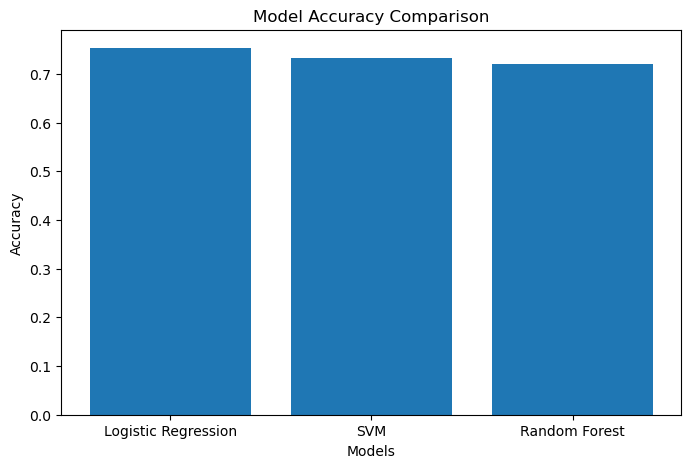

In [ ]:
sample_data = np.array([
    [6, 148, 72, 35, 0, 33.6, 0.627, 50]
])

sample_data = scaler.transform(sample_data)


prediction = rf_model.predict(sample_data)

print("\n========== Prediction Result ==========")

if prediction[0] == 1:
    print("Patient is likely to have Diabetes")
else:
    print("Patient is not likely to have Diabetes")


models = [
    'Logistic Regression',
    'SVM',
    'Random Forest',
]

accuracies = [
    lr_accuracy,
    svm_accuracy,
    rf_accuracy,
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.show()